# Plot Test Notebook

This notebook is a compact test bench for the plotting helpers in `scripts/plot_final_results.py`, including the oracle-as-reference layout.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
SCRIPTS_DIR = PROJECT_ROOT / 'scripts'

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

print('Project root:', PROJECT_ROOT)

Project root: D:\projekty\Advanced_ML_project_1


In [2]:
from plot_final_results import (
    load_results,
    load_summary,
    create_methods_boxplot,
    create_missing_rate_comparison_plot,
    create_scheme_summary_plot,
    create_mcar_trend_plot,
    create_unlabeled_improvement_over_naive_by_scheme_plot,
    create_unlabeled_improvement_over_naive_by_missing_rate_plot,
    create_delta_to_oracle_by_scheme_plot,
    create_delta_to_oracle_by_missing_rate_plot,
)

RESULTS_PATH = PROJECT_ROOT / 'outputs' / 'tables' / 'final_results.csv'
SUMMARY_PATH = PROJECT_ROOT / 'outputs' / 'tables' / 'final_summary.csv'
PLOTS_DIR = PROJECT_ROOT / 'outputs' / 'plots'

df = load_results(RESULTS_PATH)
summary_df = load_summary(SUMMARY_PATH)

print('Raw rows:', len(df))
print('Summary rows:', len(summary_df))

Raw rows: 640
Summary rows: 128


## Available values

In [3]:
print('Datasets:', sorted(df['dataset'].unique()))
print('Schemes:', sorted(df['scheme'].unique()))
print('Methods:', sorted(df['display_method'].unique()))
print('Missing rates:', sorted(df['missing_rate'].unique()))
print('Metrics:', ['accuracy', 'balanced_accuracy', 'f1', 'roc_auc'])

Datasets: ['breast_cancer', 'ionosphere', 'madelon', 'spambase']
Schemes: ['mar1', 'mar2', 'mcar', 'mnar']
Methods: ['naive', 'oracle', 'unlabeled-knn', 'unlabeled-logreg']
Missing rates: [np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5)]
Metrics: ['accuracy', 'balanced_accuracy', 'f1', 'roc_auc']


## Parameters

Change these values and rerun the plot cells below.

In [4]:
metric = 'balanced_accuracy'
dataset = 'ionosphere'
missing_rate = 0.3
generating_method = 'mcar'

## 1. Summary Plot by Scheme

Oracle should appear once on the left, with a dashed horizontal reference line.

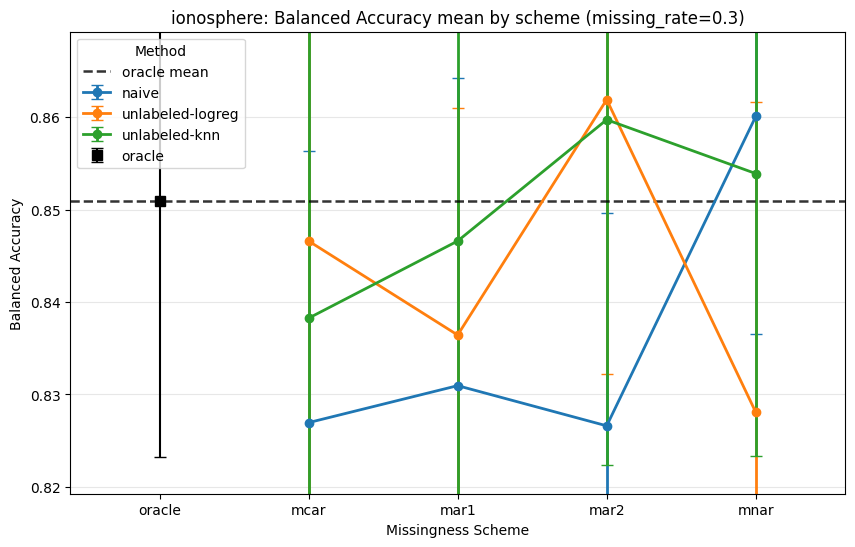

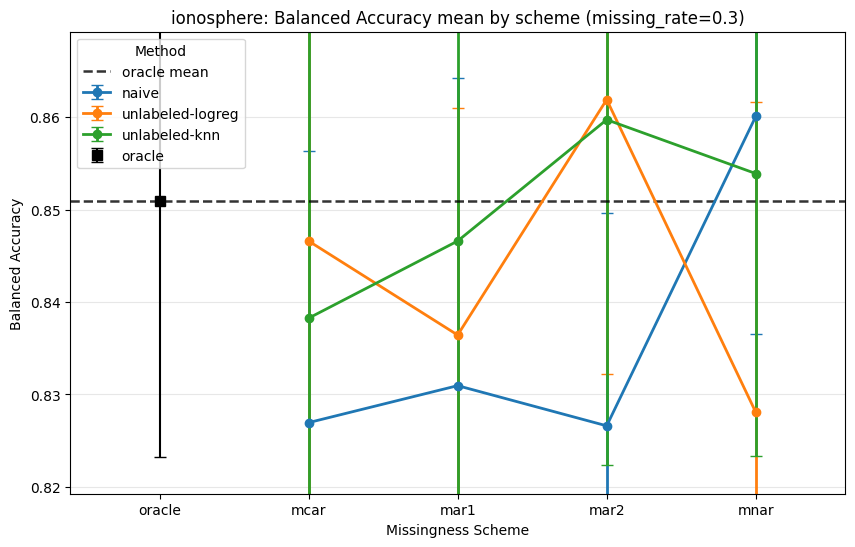

In [5]:
create_scheme_summary_plot(
    summary_df=summary_df,
    metric=metric,
    dataset=dataset,
    missing_rate=missing_rate,
    output_path=PLOTS_DIR / f'{dataset}_{metric}_scheme_summary_test.png',
    show=True,
)

## 2. MCAR Trend Plot

Oracle should appear once on the left, with a dashed horizontal reference line.

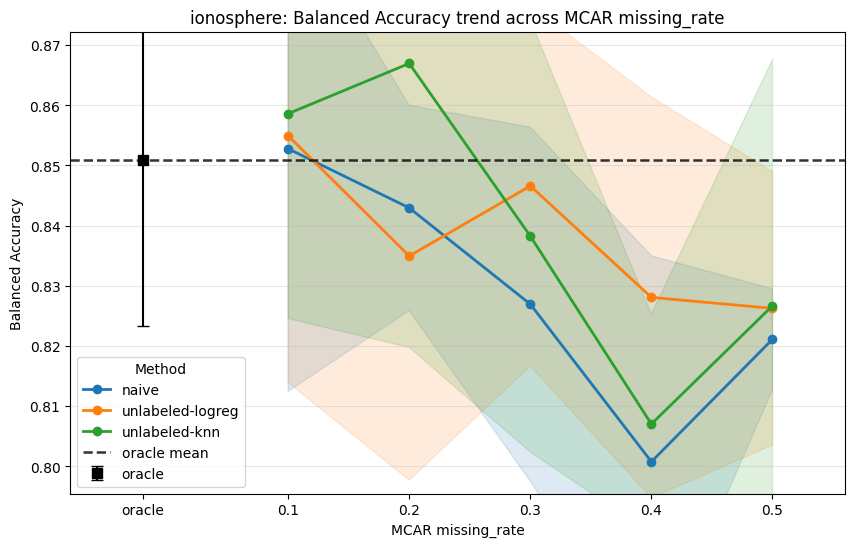

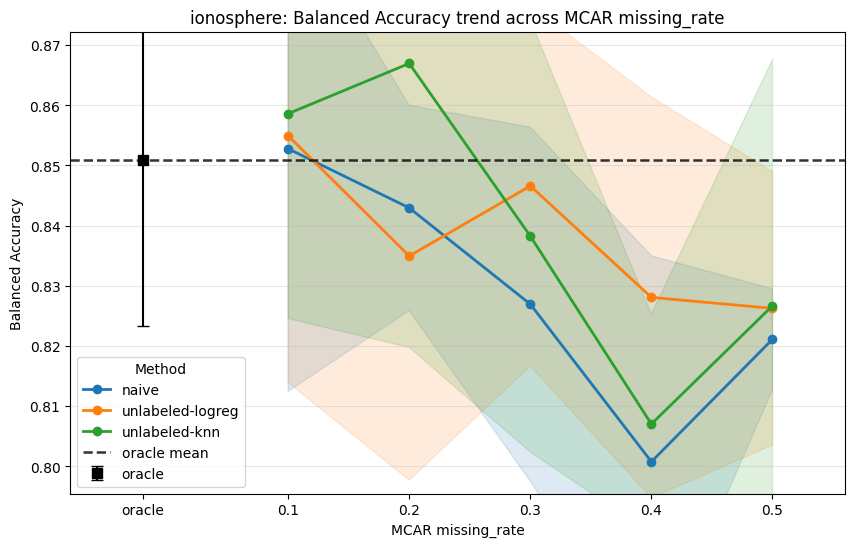

In [6]:
create_mcar_trend_plot(
    summary_df=summary_df,
    metric=metric,
    dataset=dataset,
    output_path=PLOTS_DIR / f'{dataset}_{metric}_mcar_trend_test.png',
    show=True,
)

## 3. Boxplot by Scheme

Oracle should appear once on the left as a separate reference boxplot.

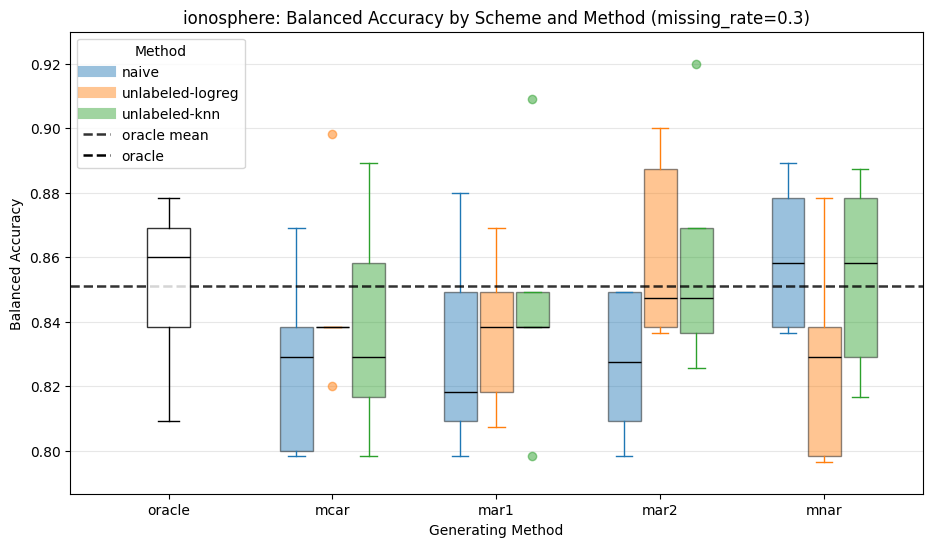

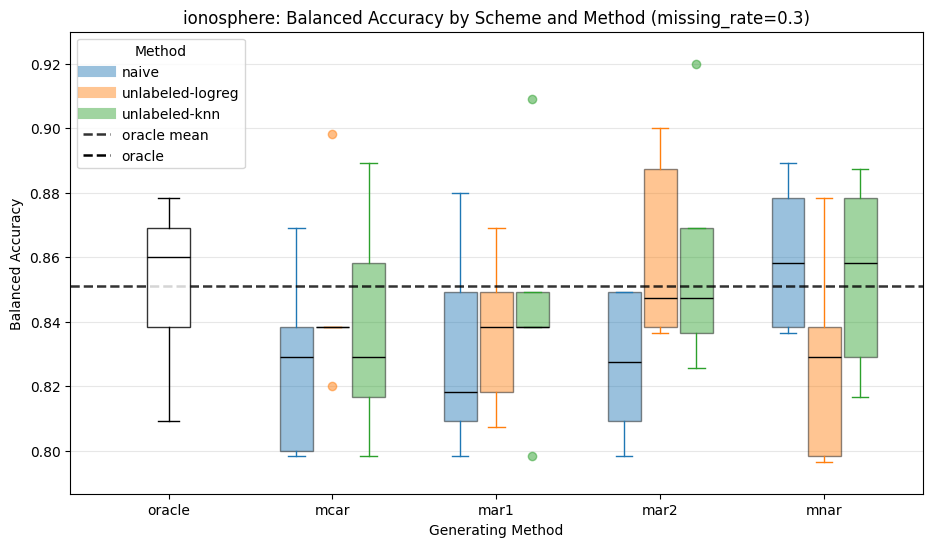

In [7]:
create_methods_boxplot(
    df=df,
    metric=metric,
    missing_rate=missing_rate,
    dataset=dataset,
    output_path=PLOTS_DIR / f'{dataset}_{metric}_methods_boxplot_test.png',
    show=True,
)

## 4. Boxplot by MCAR Missing Rate

Oracle should appear once on the left as a separate reference boxplot.

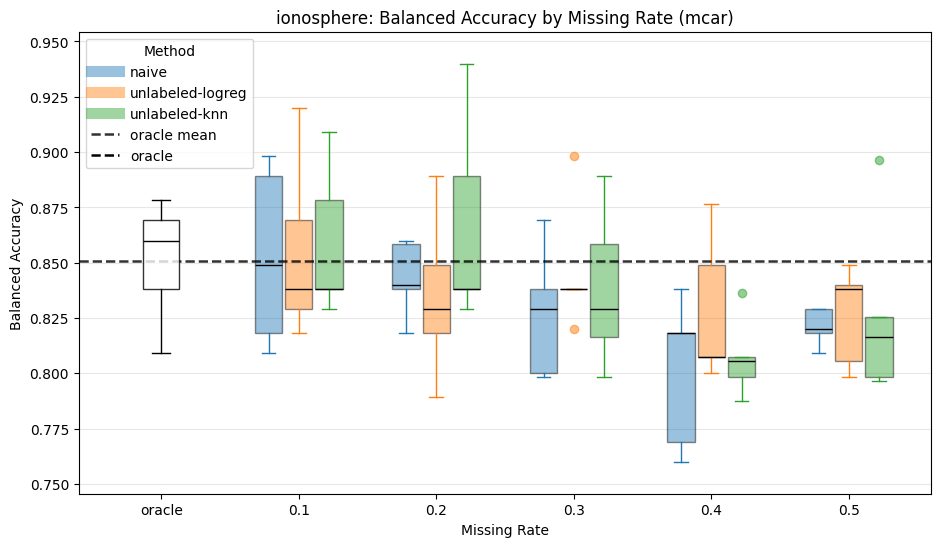

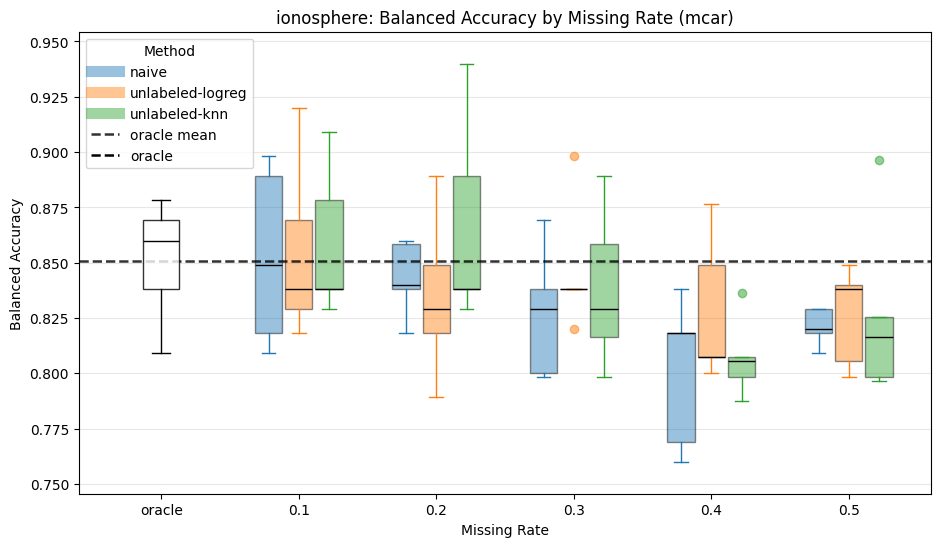

In [8]:
create_missing_rate_comparison_plot(
    df=df,
    metric=metric,
    dataset=dataset,
    generating_method=generating_method,
    output_path=PLOTS_DIR / f'{dataset}_{metric}_{generating_method}_missing_rate_boxplot_test.png',
    show=True,
)

## 5. Unlabeled Improvement Over Naive by Scheme

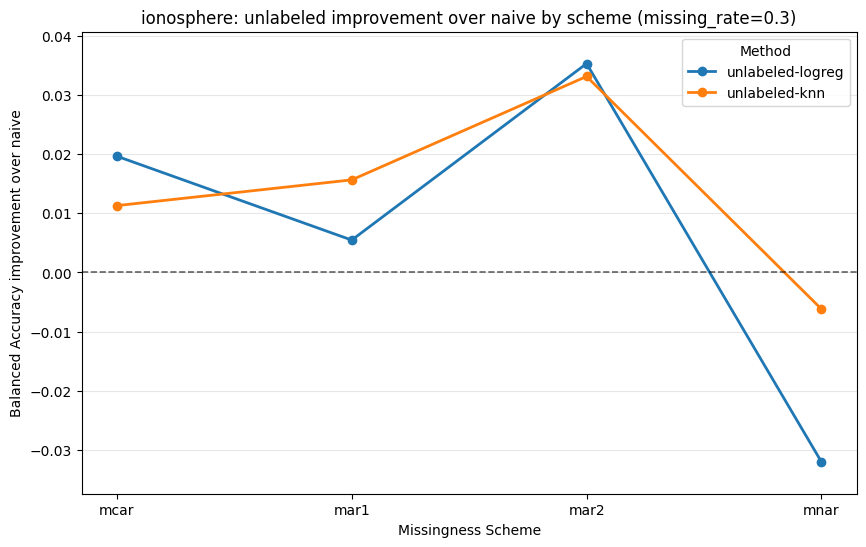

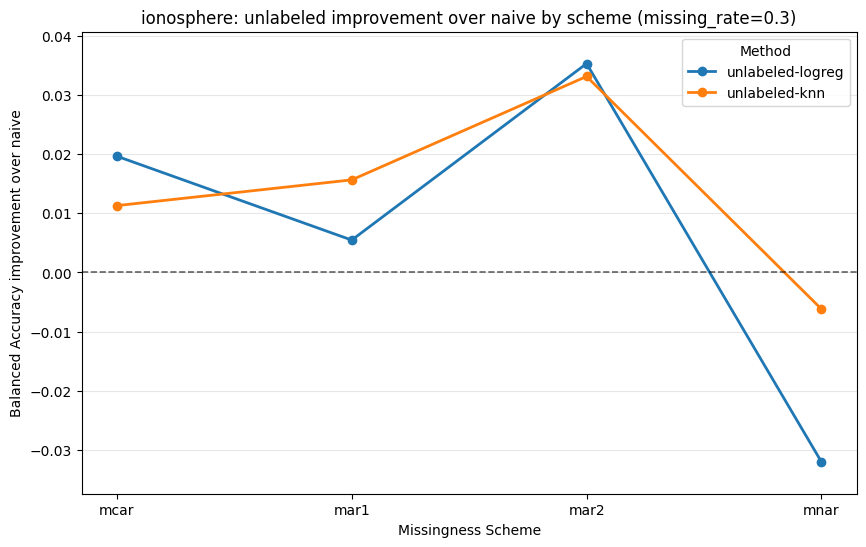

In [9]:
create_unlabeled_improvement_over_naive_by_scheme_plot(
    summary_df=summary_df,
    metric=metric,
    dataset=dataset,
    missing_rate=missing_rate,
    output_path=PLOTS_DIR / f'{dataset}_{metric}_improvement_over_naive_by_scheme_test.png',
    show=True,
)

## 6. Unlabeled Improvement Over Naive by Missing Rate

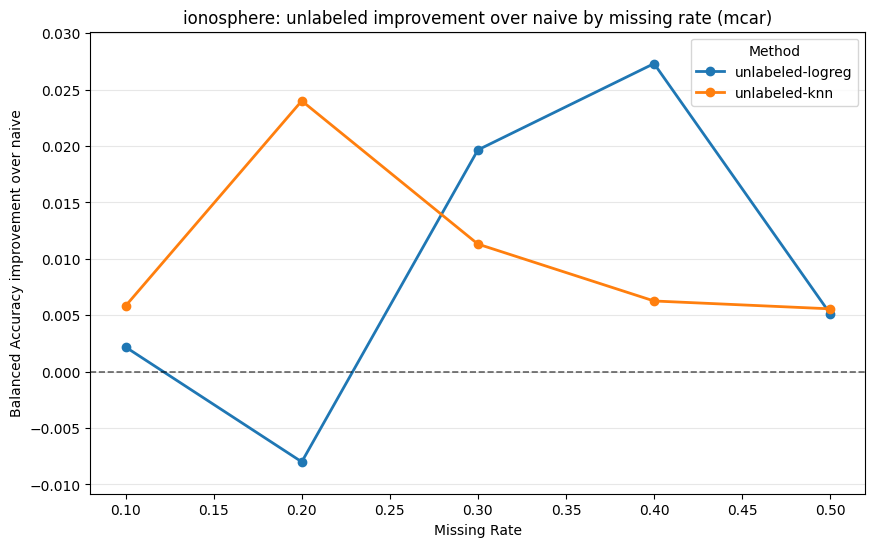

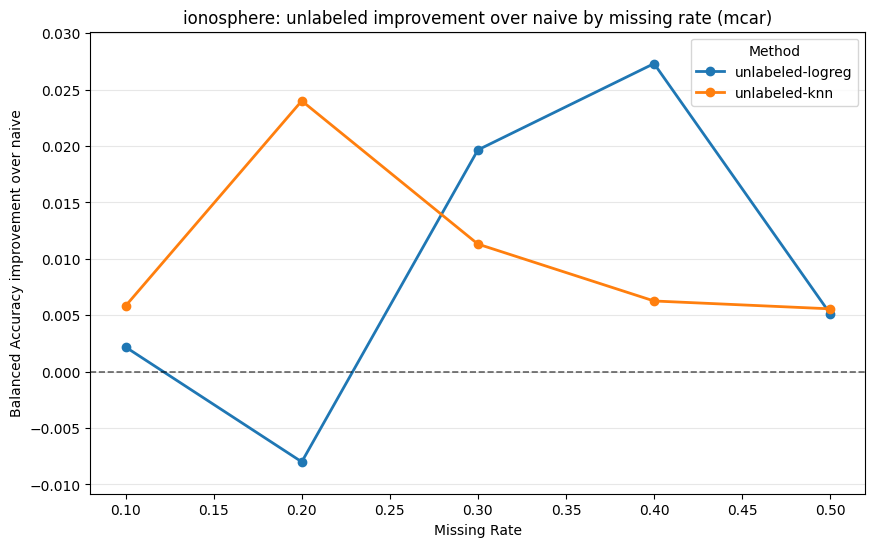

In [10]:
create_unlabeled_improvement_over_naive_by_missing_rate_plot(
    summary_df=summary_df,
    metric=metric,
    dataset=dataset,
    generating_method=generating_method,
    output_path=PLOTS_DIR / f'{dataset}_{metric}_improvement_over_naive_by_missing_rate_test.png',
    show=True,
)

## 7. Delta to Oracle by Scheme

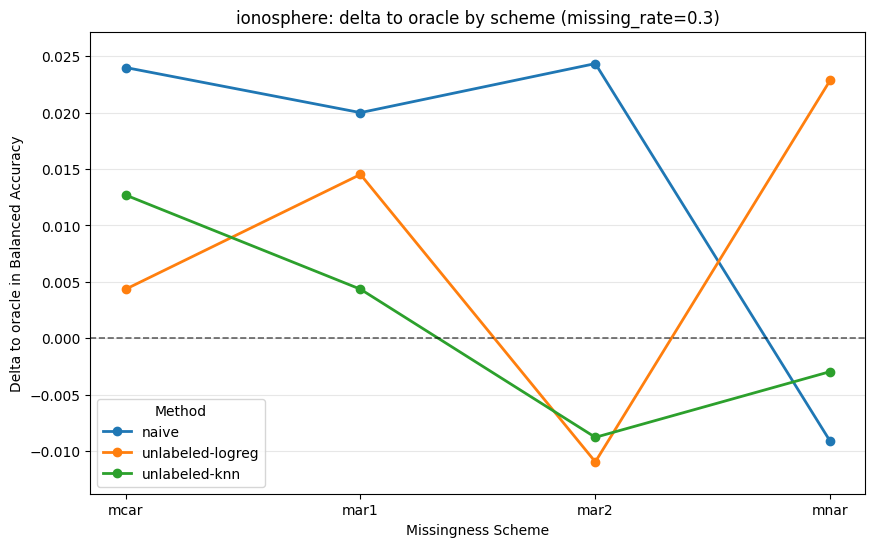

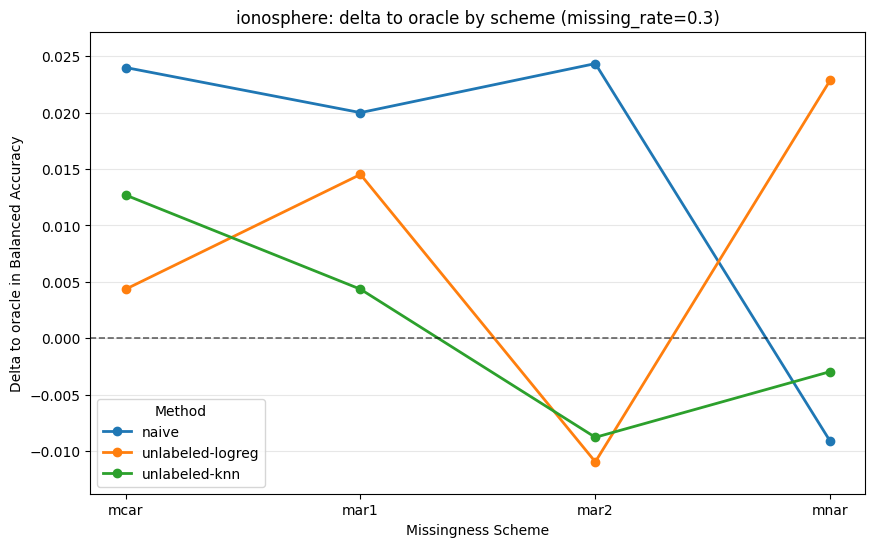

In [11]:
create_delta_to_oracle_by_scheme_plot(
    summary_df=summary_df,
    metric=metric,
    dataset=dataset,
    missing_rate=missing_rate,
    output_path=PLOTS_DIR / f'{dataset}_{metric}_delta_to_oracle_by_scheme_test.png',
    show=True,
)

## 8. Delta to Oracle by Missing Rate

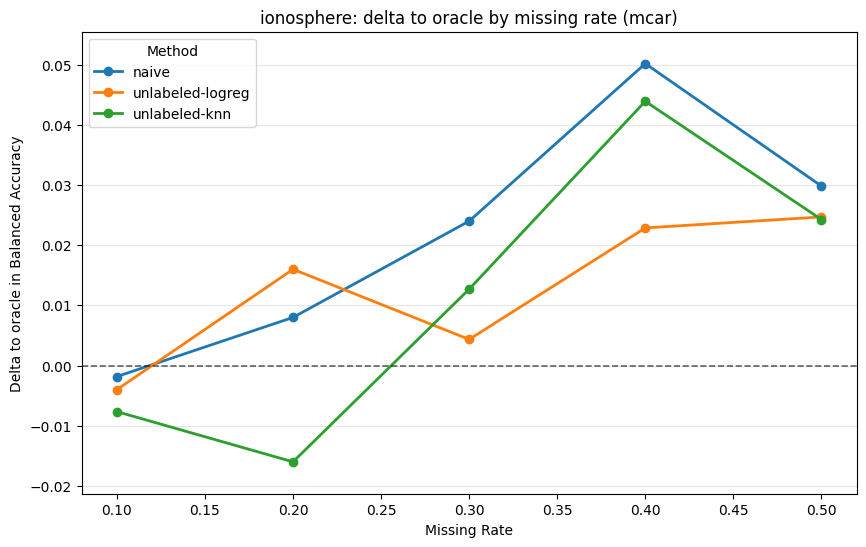

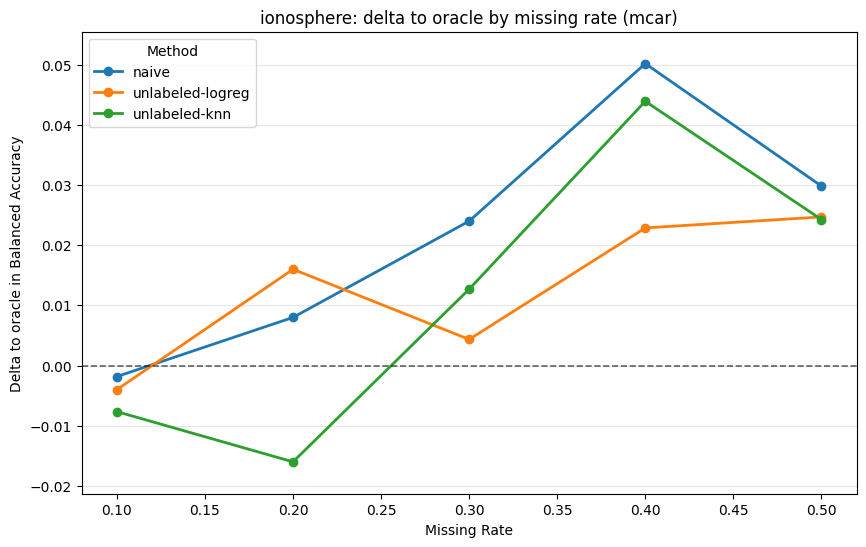

In [12]:
create_delta_to_oracle_by_missing_rate_plot(
    summary_df=summary_df,
    metric=metric,
    dataset=dataset,
    generating_method=generating_method,
    output_path=PLOTS_DIR / f'{dataset}_{metric}_delta_to_oracle_by_missing_rate_test.png',
    show=True,
)

## Quick presets

- `dataset = 'breast_cancer'`
- `dataset = 'ionosphere'`
- `metric = 'balanced_accuracy'`
- `metric = 'roc_auc'`
- `missing_rate = 0.3`
- `generating_method = 'mcar'`